## Сэмплы строк: чистые vs аугментированные vs вход модели

Для каждой строки 4 панели:
1. **clean** — исходный кроп (пропорции сохранены), заголовок = текст-метка
2. **augmented** — после `Augmenter(train=True)` (то же, что на обучении)
3. **input 384²** — что РЕАЛЬНО видит энкодер: выход процессора TrOCR (квадрат 384×384, без сохранения пропорций), де-нормализован обратно
4. **input 384² (aug)** — то же для аугментированной

`AR` в заголовке = ширина/высота кропа, `Nch` = число символов.

In [1]:
import sys, random
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "src" / "finetune").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
print("project root:", ROOT)

import numpy as np
import matplotlib.pyplot as plt
from omegaconf import OmegaConf
from transformers import AutoImageProcessor
from src.finetune import build_sources, Augmenter

cfg = OmegaConf.load(ROOT / "configs" / "finetune.yaml")
aug = Augmenter(train=True, p=1.0)            # always augment, to see the effect

# the exact image preprocessing the model gets (square resize + normalize)
proc_src = ROOT / cfg.trainer.output_dir / "best"
proc_src = str(proc_src) if proc_src.exists() else "microsoft/trocr-small-handwritten"
improc = AutoImageProcessor.from_pretrained(proc_src)
_mean = np.array(improc.image_mean, np.float32).reshape(3, 1, 1)
_std = np.array(improc.image_std, np.float32).reshape(3, 1, 1)
print("image processor:", proc_src, "size:", improc.size)


def model_input(img):
    """What the encoder actually sees: processor output, de-normalized back to viewable."""
    pv = improc(images=img.convert("RGB"), return_tensors="pt").pixel_values[0].numpy()
    return np.clip((pv * _std + _mean).transpose(1, 2, 0), 0, 1)


def preview(ds, name, n=6, seed=0):
    if ds is None or len(ds) == 0:
        print(f"{name}: empty"); return
    idxs = random.Random(seed).sample(range(len(ds)), min(n, len(ds)))
    fig, axes = plt.subplots(len(idxs), 4, figsize=(16, 2.0 * len(idxs)), squeeze=False)
    for r, i in enumerate(idxs):
        s = ds[i]; img = s["image"].convert("RGB"); text = s["text"]
        w, h = img.size; ar = w / max(h, 1)
        panels = [(img, text[:60]),
                  (aug(img), "augmented"),
                  (model_input(img), f"input 384\u00b2  AR={ar:.1f}  {len(text)}ch"),
                  (model_input(aug(img)), "input 384\u00b2 (aug)")]
        for c, (im, title) in enumerate(panels):
            axes[r, c].imshow(im); axes[r, c].axis("off")
            axes[r, c].set_title(title, fontsize=8, loc="left")
    fig.suptitle(name, fontsize=12); plt.tight_layout(); plt.show()


def show_source(name, n=6, seed=0):
    """Build ONE source (clean images) from the config and preview it."""
    spec = OmegaConf.create({name: OmegaConf.to_container(cfg.data.sources[name], resolve=True)})
    spec[name]["enabled"] = True
    clean = Augmenter(train=False)
    srcs = build_sources(spec, ROOT, clean, clean)
    if not srcs:
        print(f"{name}: no data found - build it first (scripts/download/...)"); return
    preview(srcs[0].train, f"{name} [{srcs[0].lang}]", n=n, seed=seed)

project root: /workspace/HDD/handwriting-recognition/recognition
image processor: /workspace/HDD/handwriting-recognition/recognition/outputs/trocr_small_bi_finetune_with_hwr200_cleaned/best size: {'height': 384, 'width': 384}


In [2]:
# !pip install jiwer

source 'cyrillic' [ru]: train=72284 test=1544


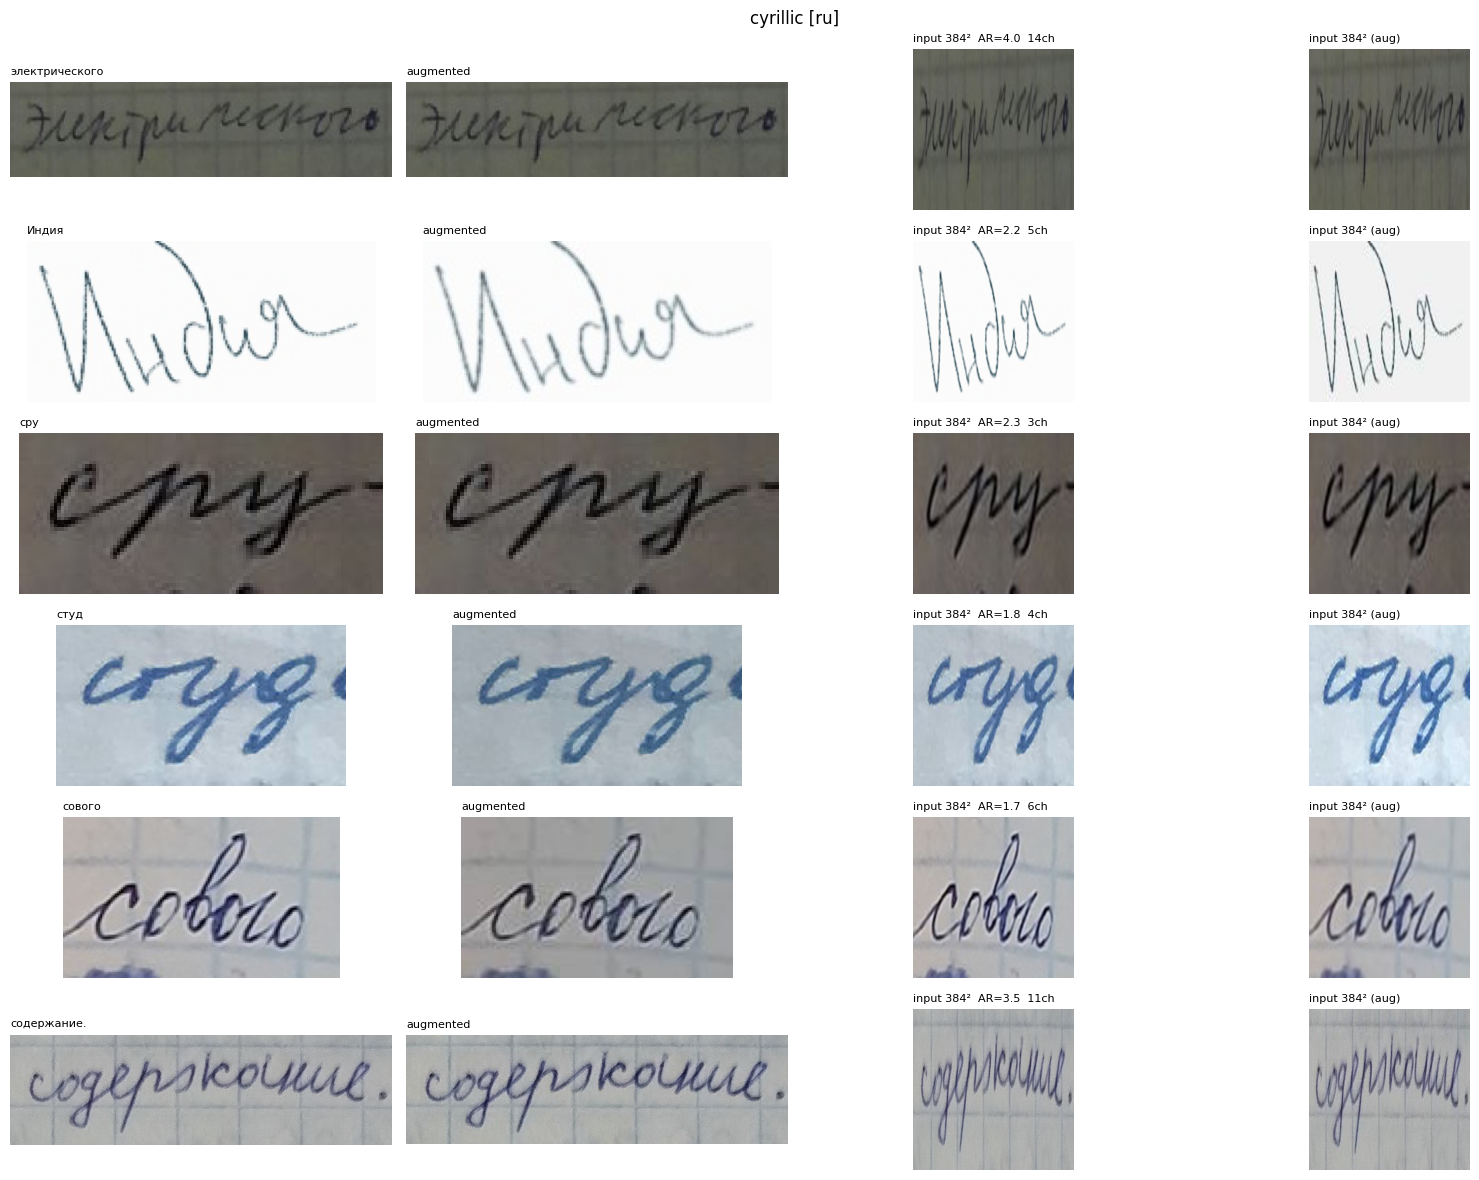

In [3]:
# words (short) - squashing should be harmless here
show_source("cyrillic", n=6)

source 'school_notebooks_ru' [ru]: train=61889 test=5470


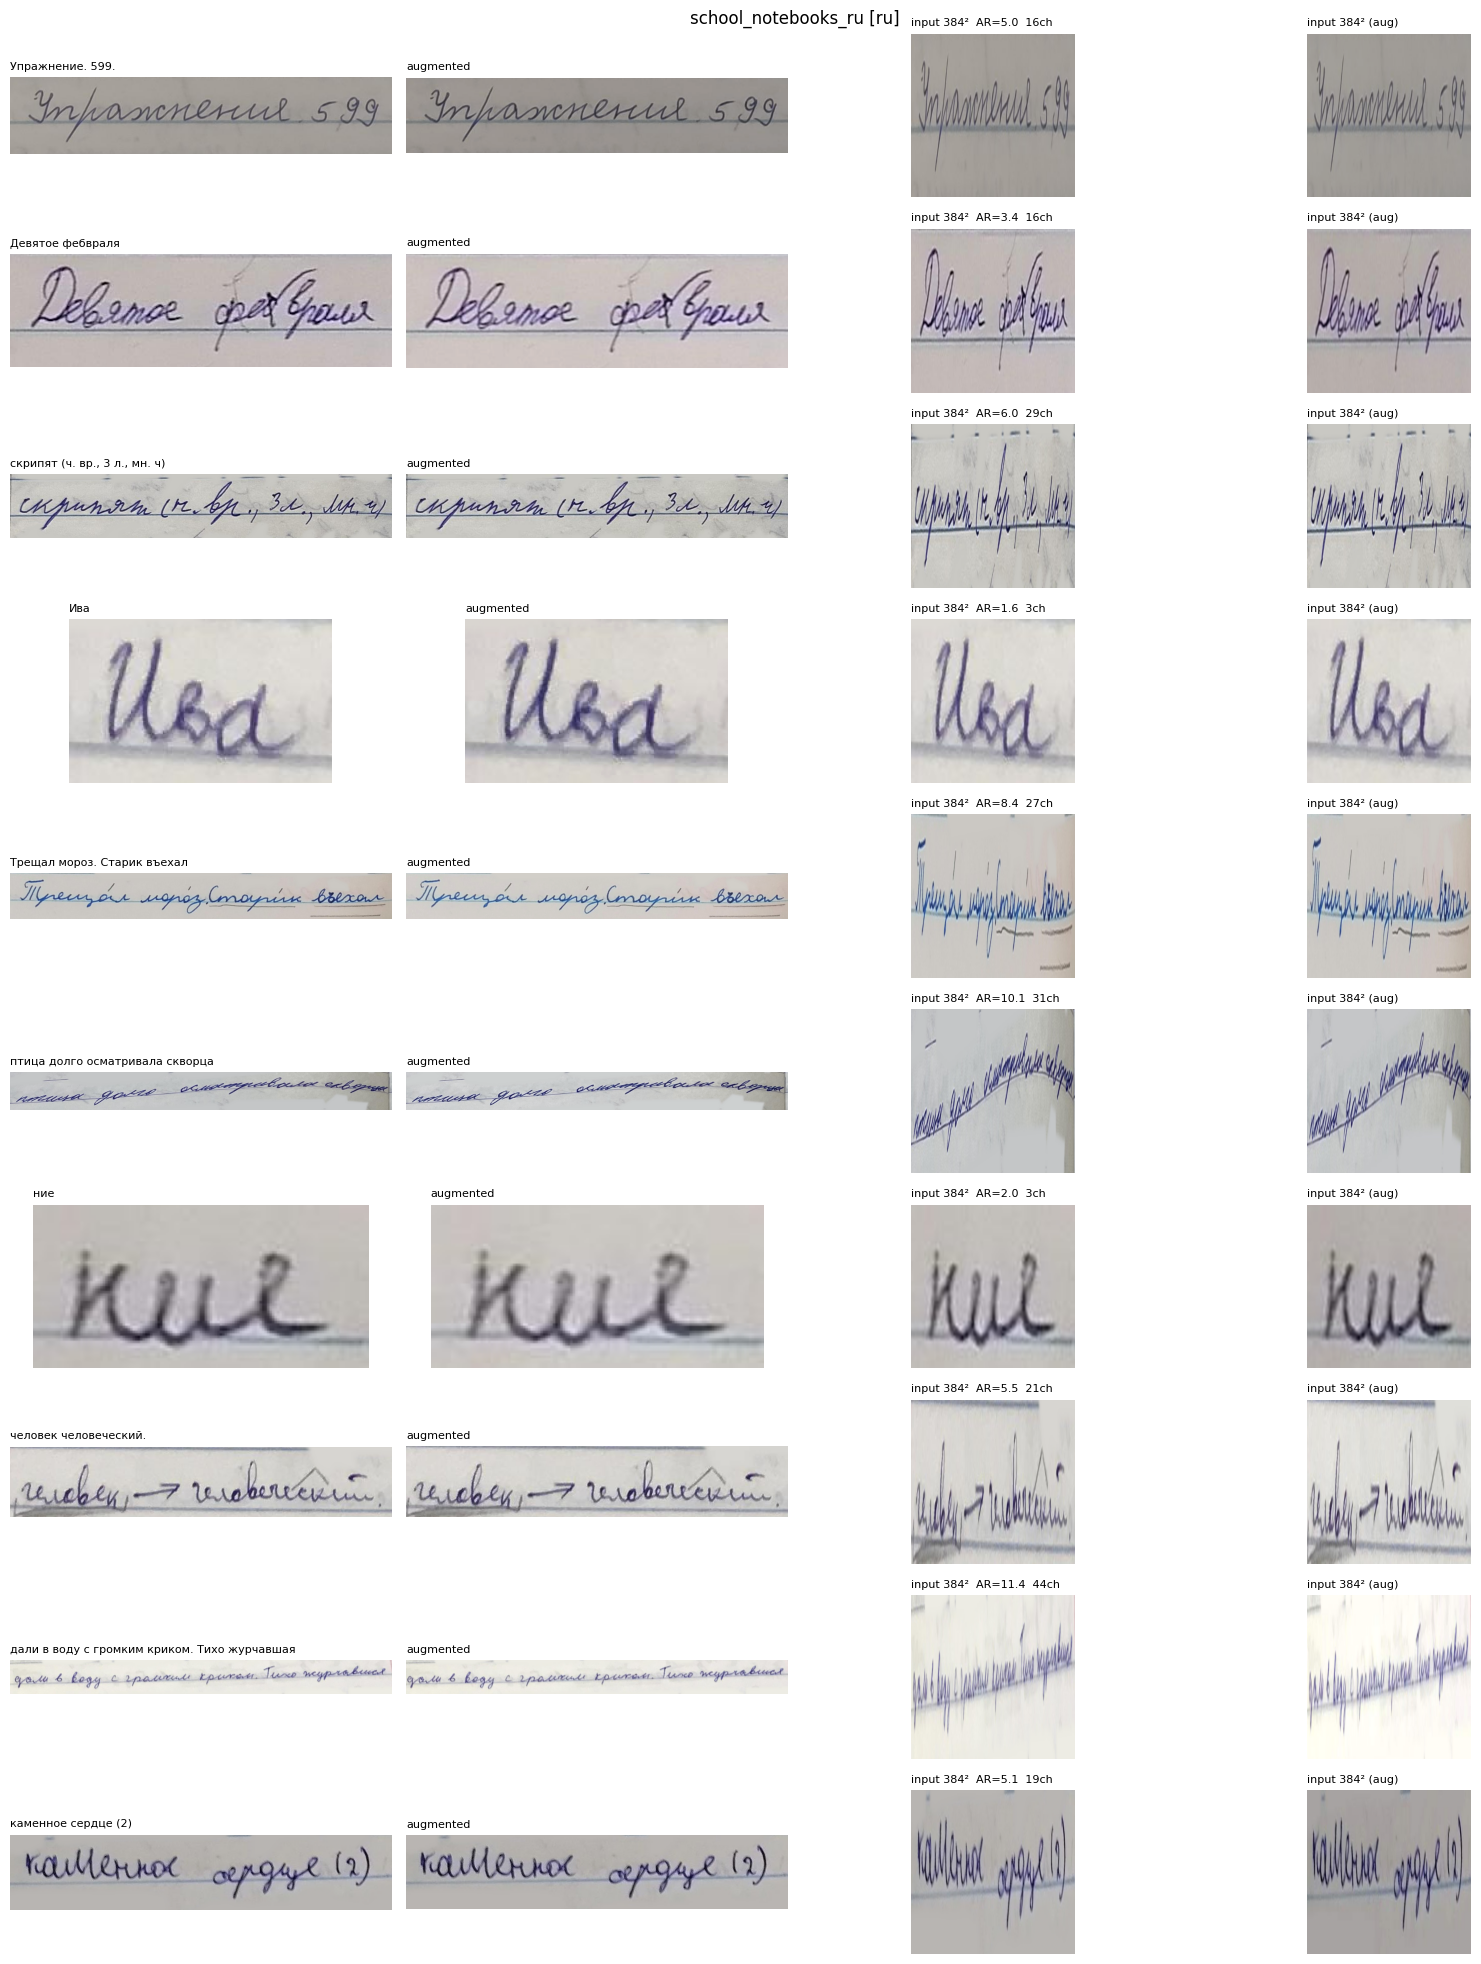

In [4]:
# real RU lines - prime suspect for long-line squashing
show_source("school_notebooks_ru", n=10)

source 'iam' [en]: train=7458 test=2915


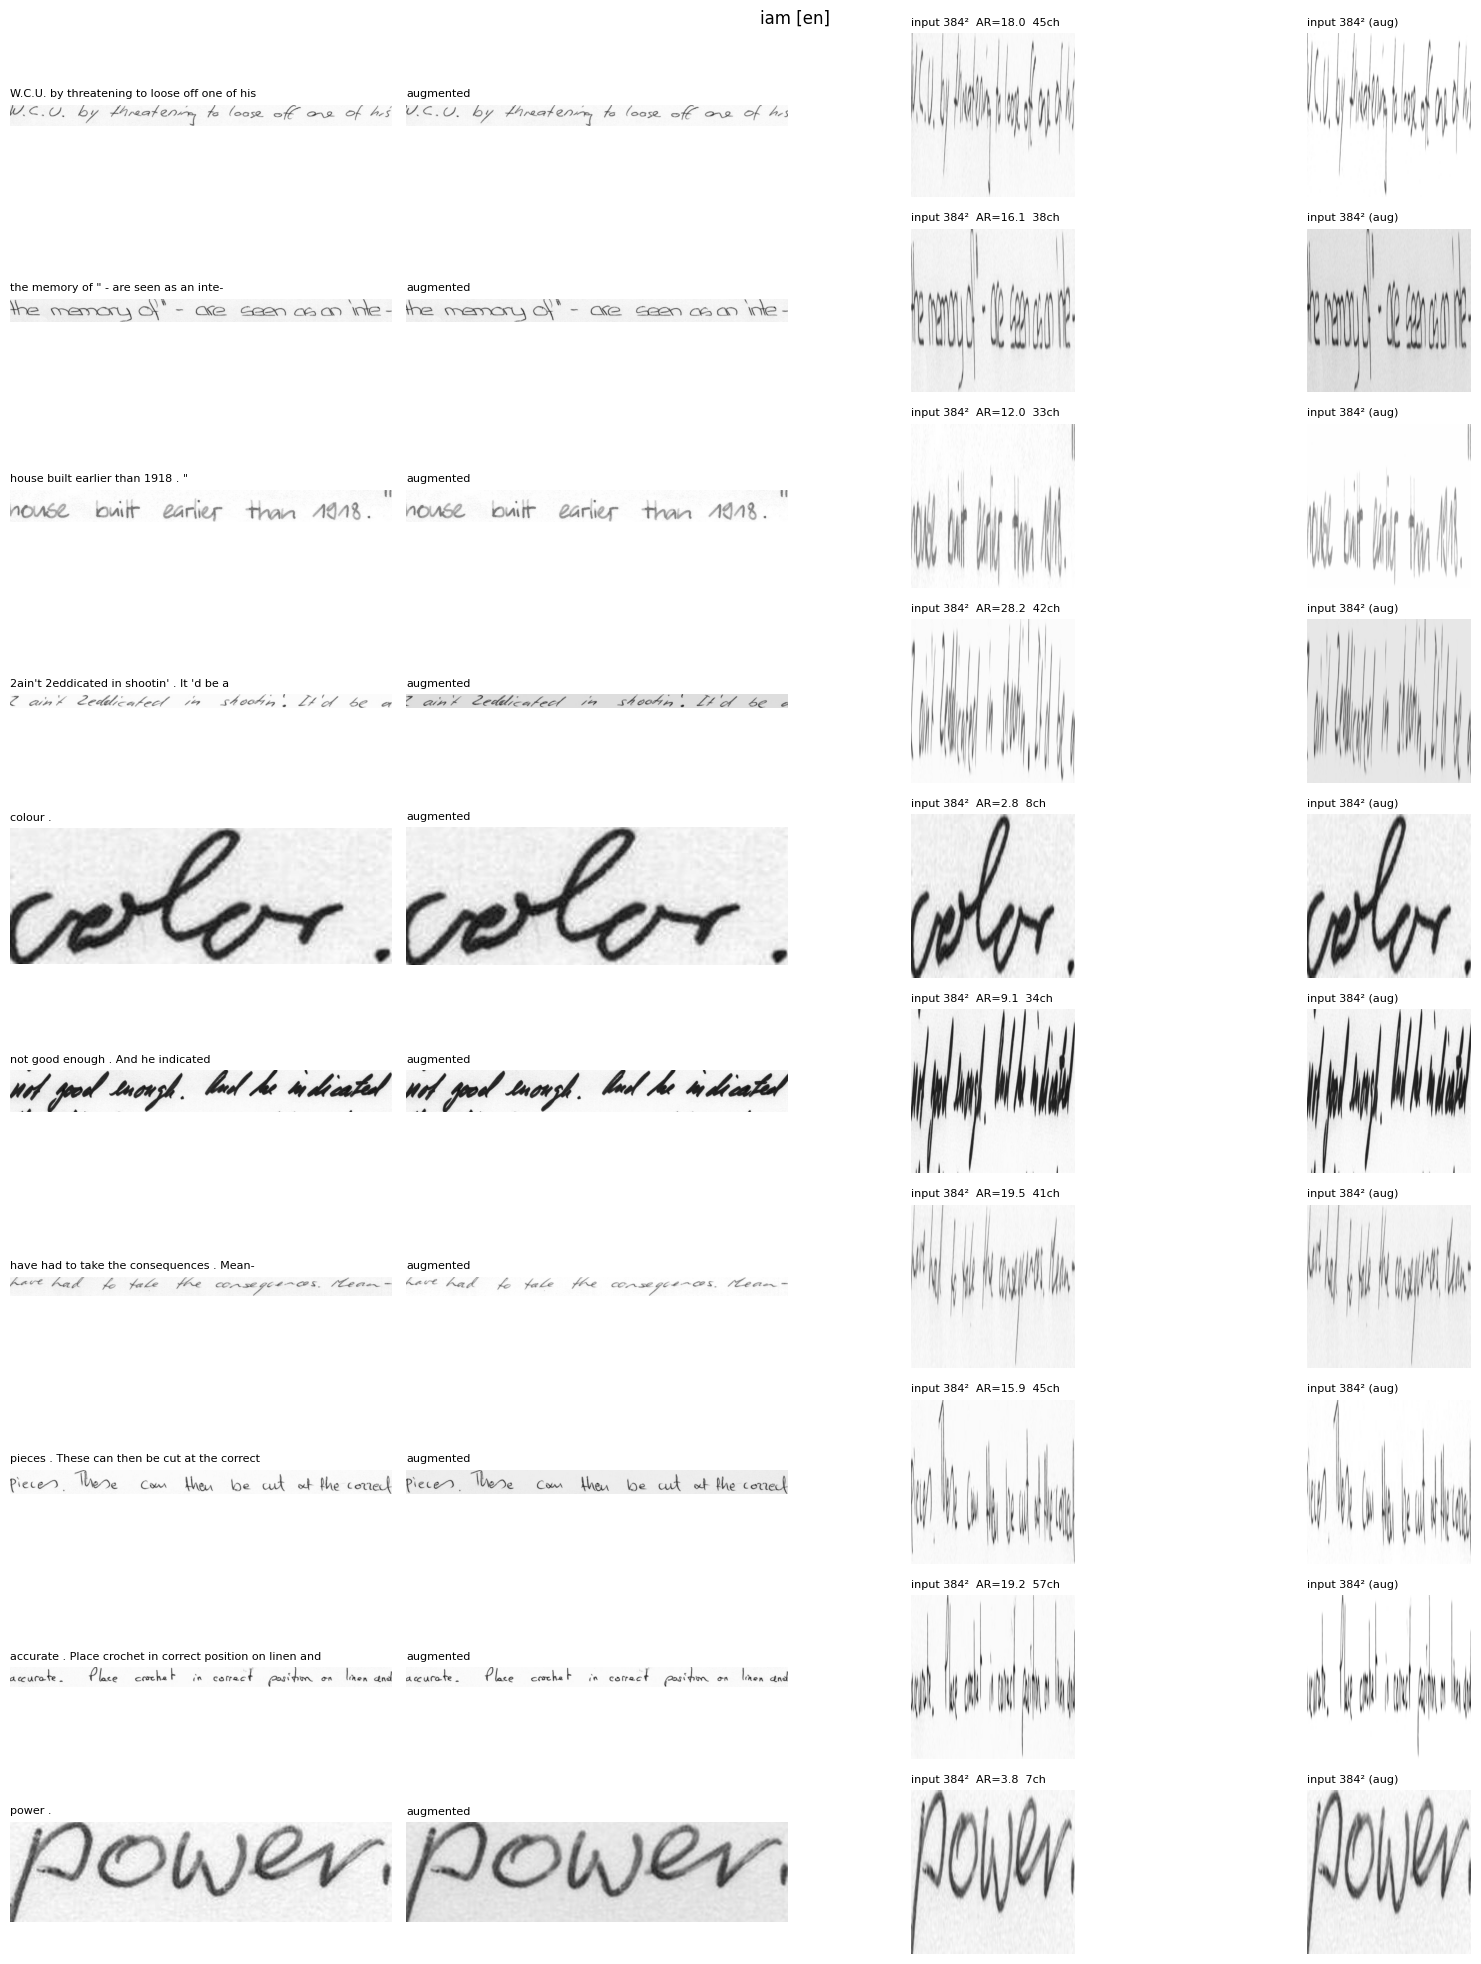

In [5]:
# English lines
show_source("iam", n=10)

In [6]:
# !pip install datasets

source 'cvl' [en]: train=13441 test=0


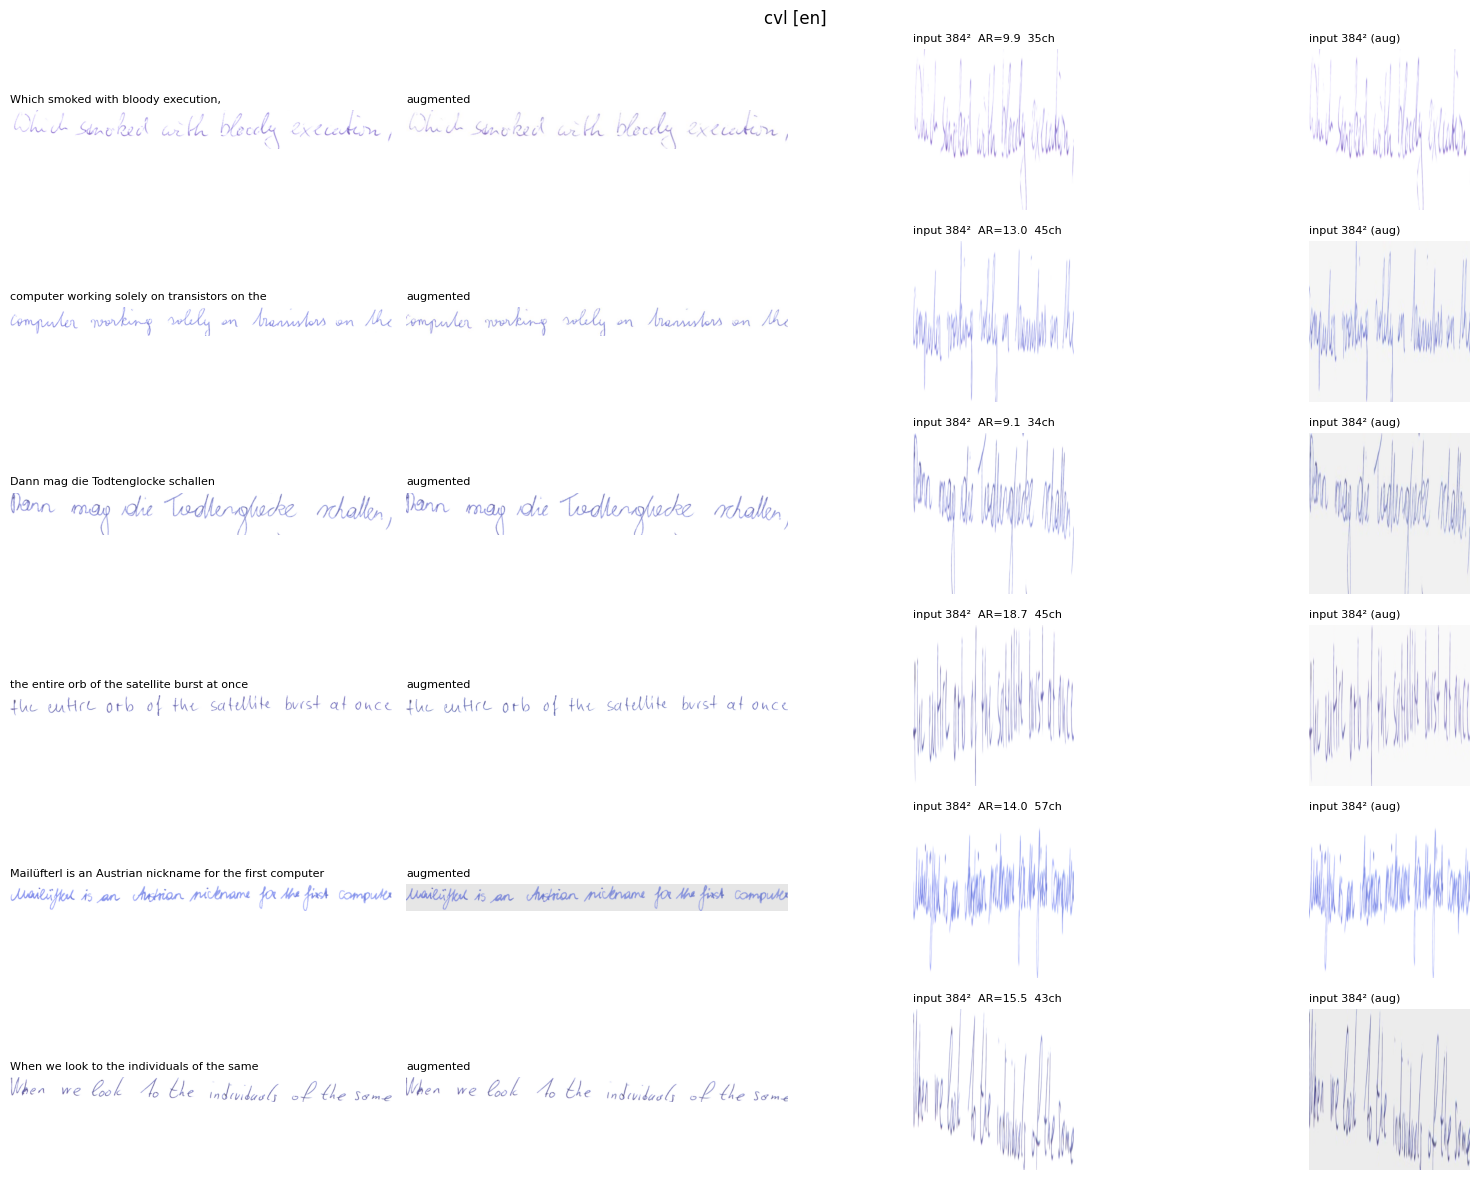

In [7]:
show_source("cvl", n=6)

source 'hwr200' [ru]: train=45875 test=5097


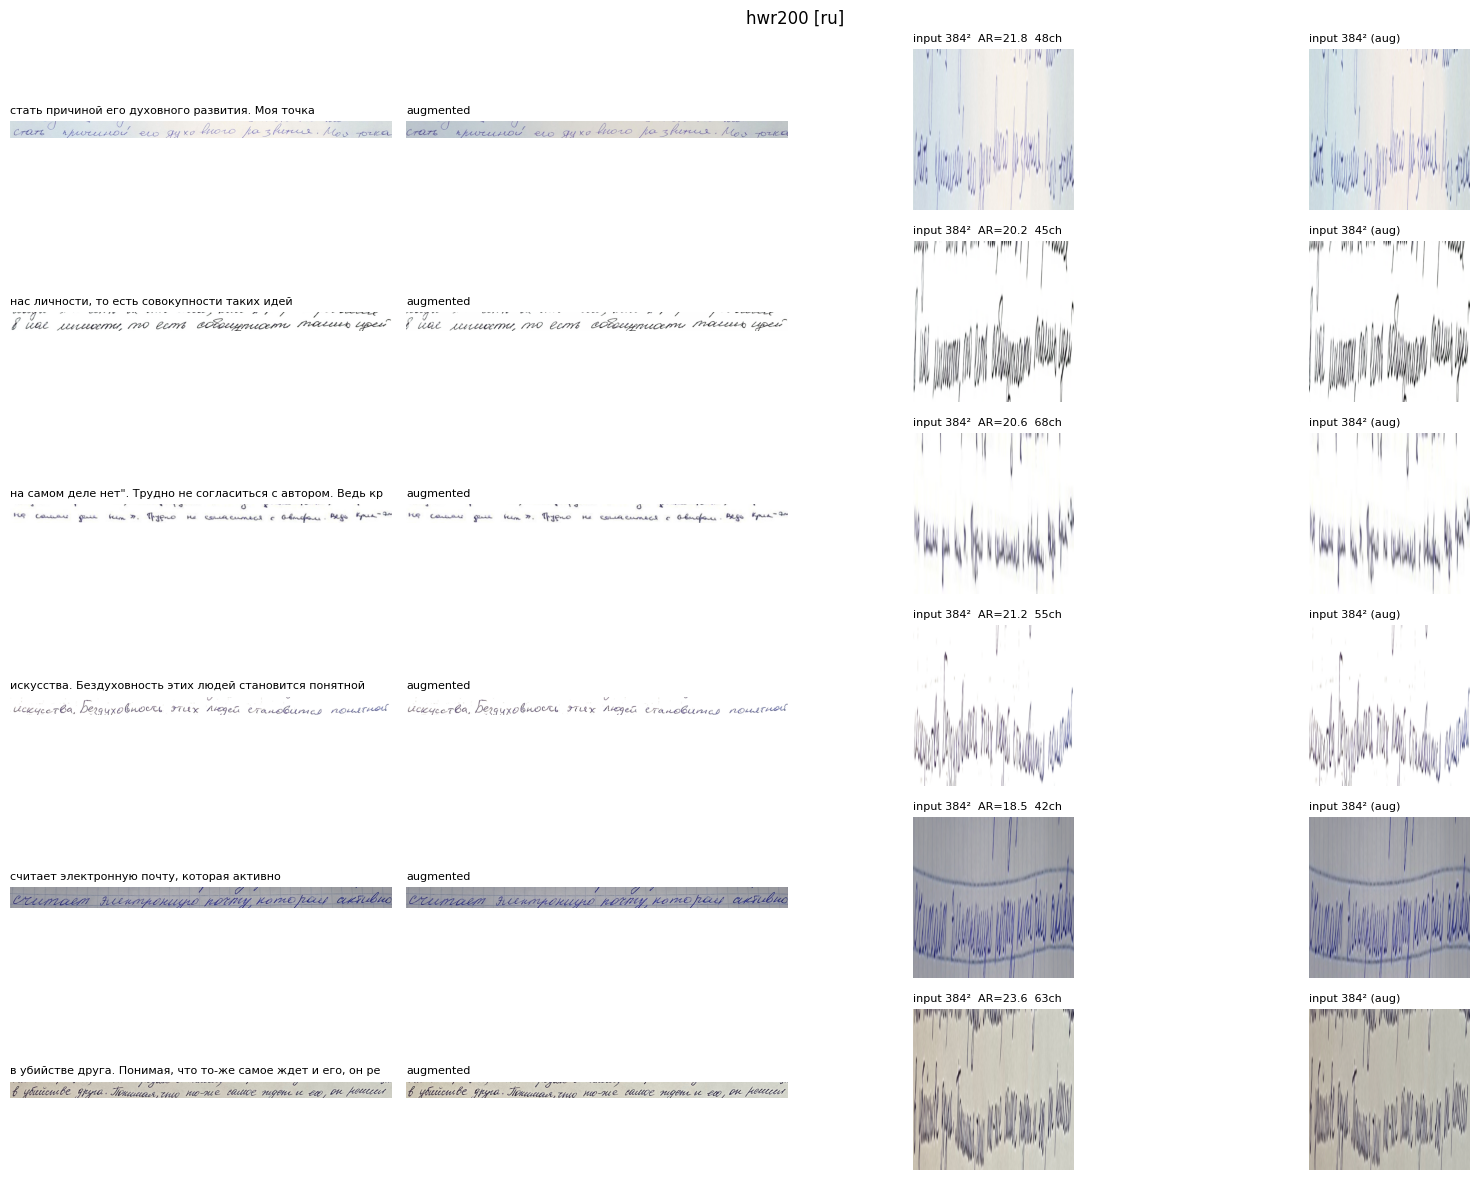

In [9]:
# hwr200 (kind: pairs)
show_source("hwr200", n=6)